In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("ggplot") 

In [2]:
import sys
print(sys.executable)

c:\Projects\Stock-Predictive-Dashboard\venv\Scripts\python.exe


In [5]:
df=pd.read_csv("../data/clean_stock.csv")

In [6]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
1,2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2,2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
3,2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000
4,2020-01-08,73.017815,73.318854,71.565599,71.565599,132079200


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1258 non-null   str    
 1   Close   1258 non-null   float64
 2   High    1258 non-null   float64
 3   Low     1258 non-null   float64
 4   Open    1258 non-null   float64
 5   Volume  1258 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 71.4 KB


In [9]:
df.shape

(1258, 6)

In [10]:
df.describe()

,Close,High,Low,Open,Volume
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.377786,152.899566,149.680871,151.223470,9.057103e+07
std,41.851999,41.992363,41.629303,41.795805,5.324438e+07
min,54.163708,55.160705,51.324804,55.059316,2.323470e+07
25%,126.279119,127.397077,124.278508,125.724360,5.546825e+07
50%,149.968613,151.709757,148.037172,149.788890,7.628335e+07
75%,175.902031,177.452409,174.337230,175.708215,1.077425e+08
max,257.375549,258.448710,255.994390,256.550832,4.265100e+08


In [11]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Date"] = pd.to_datetime(df["Date"])

In [14]:
df.set_index("Date", inplace=True)

In [15]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000
2020-01-08,73.017815,73.318854,71.565599,71.565599,132079200


In [16]:
plt.figure(figsize=(15,6))

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

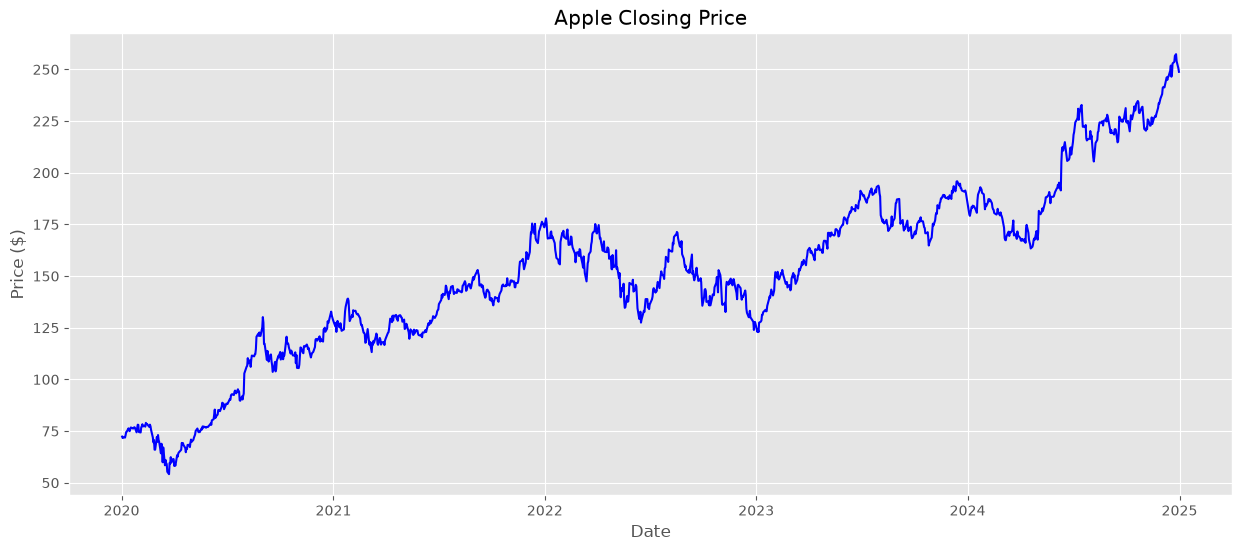

In [17]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df["Close"], color="blue")

plt.title("Apple Closing Price")

plt.xlabel("Date")

plt.ylabel("Price ($)")

plt.grid(True)

plt.show()

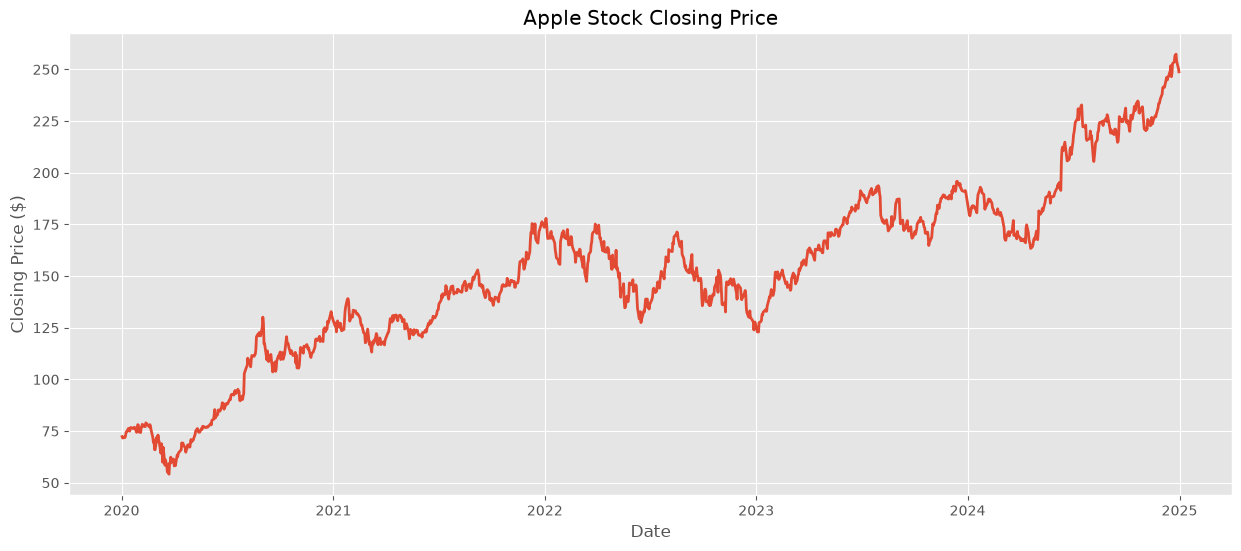

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(df.index, df["Close"], linewidth=2)

plt.title("Apple Stock Closing Price")

plt.xlabel("Date")

plt.ylabel("Closing Price ($)")

plt.grid(True)

plt.show()

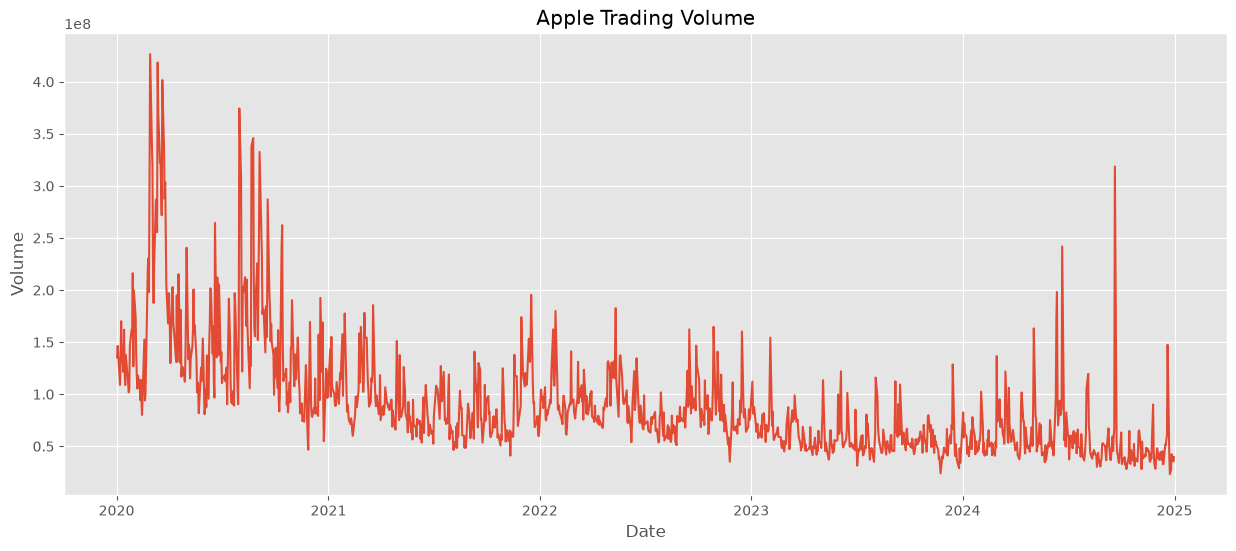

In [19]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df["Volume"])

plt.title("Apple Trading Volume")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.grid(True)

plt.show()

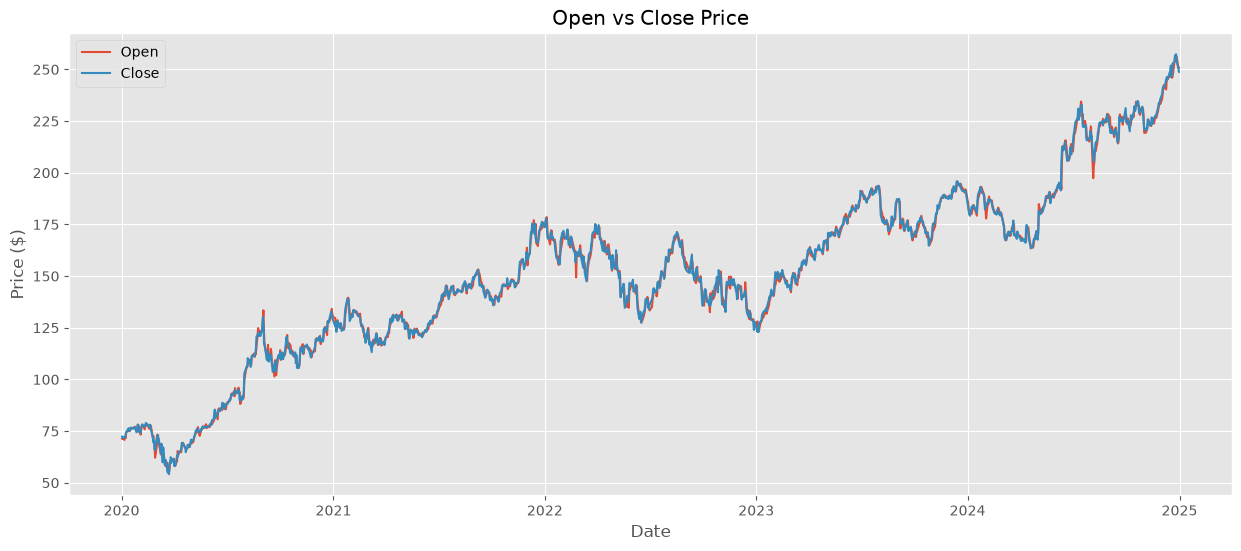

In [20]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df["Open"], label="Open")

plt.plot(df.index, df["Close"], label="Close")

plt.title("Open vs Close Price")

plt.xlabel("Date")

plt.ylabel("Price ($)")

plt.legend()

plt.grid(True)

plt.show()

In [6]:
stock_df = df.copy()

Creating a 20 - day moving Average 


In [22]:
stock_df["MA20"]=stock_df["Close"].rolling(window=20).mean()

Creating 50 -day Moving Average


In [23]:
stock_df=stock_df["Close"].rolling(window=50).mean()

In [24]:
stock_df.head(25)

Date
2020-01-02   NaN
2020-01-03   NaN
2020-01-06   NaN
2020-01-07   NaN
2020-01-08   NaN
2020-01-09   NaN
2020-01-10   NaN
2020-01-13   NaN
2020-01-14   NaN
2020-01-15   NaN
2020-01-16   NaN
2020-01-17   NaN
2020-01-21   NaN
2020-01-22   NaN
2020-01-23   NaN
2020-01-24   NaN
2020-01-27   NaN
2020-01-28   NaN
2020-01-29   NaN
2020-01-30   NaN
2020-01-31   NaN
2020-02-03   NaN
2020-02-04   NaN
2020-02-05   NaN
2020-02-06   NaN
Name: Close, dtype: float64

In [7]:
stock_df["Daily_Return"] = stock_df["Close"].pct_change()

In [26]:
print(stock_df.head())

Date
2020-01-02   NaN
2020-01-03   NaN
2020-01-06   NaN
2020-01-07   NaN
2020-01-08   NaN
Name: Close, dtype: float64


In [8]:
print(stock_df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return'], dtype='str')


In [9]:
type(stock_df)

pandas.DataFrame

In [11]:
stock_df["Volatility"] = stock_df["Daily_Return"].rolling(window=20).std()

In [12]:
stock_df["Lag_1"] = stock_df["Close"].shift(1)

stock_df["Lag_2"] = stock_df["Close"].shift(2)

stock_df["Lag_3"] = stock_df["Close"].shift(3)


In [13]:
stock_df = stock_df.dropna()

In [14]:
from prophet import Prophet

NameError: name 'df' is not defined